# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Kevin Teng

**Date:** 9/11/26

In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('./data/ForeignGifts_edu.csv') 

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


Text(0.5, 0, 'Amount')

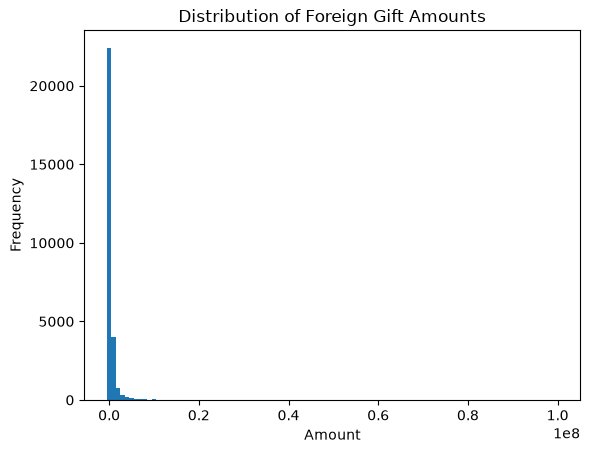

In [38]:
#Question 2 part 2
print(df["Foreign Gift Amount"].describe())
df["Foreign Gift Amount"].plot(kind='hist', bins=100, title='Distribution of Foreign Gift Amounts')
plt.xlabel('Amount')

Most foreign gifts amounts are on the lower end with a median of $94,615. There are also significant outliers with a donation being $100,000,000, which causes the mean foreign gift to be significantly higher than the median at $588,000. Most gifts fall in the lower dollar amount ranges, but there are a few exteremely large gifts, which causes the graph to expand the distribution to the right.

In [59]:
#Question 2 part 3
value_counts_table = df["Gift Type"].value_counts().rename_axis('Gift Type').reset_index(name = "Count")
value_counts_table

,Gift Type,Count
0,Contract,17274
1,Monetary Gift,10936
2,Real Estate,11


In [62]:
contract_count = df["Gift Type"].value_counts()["Contract"]
mg_count = df["Gift Type"].value_counts()["Monetary Gift"]
re_count = df["Gift Type"].value_counts()["Real Estate"]
total = contract_count + mg_count + re_count

print ("Contract Percentage: ", (contract_count / total) * 100)
print ("Monetary Gift Percentage: ", (mg_count / total) * 100)
print ("Real Estate Percentage: ", (re_count / total) * 100)

Contract Percentage:  61.20973742957372
Monetary Gift Percentage:  38.75128450444704
Real Estate Percentage:  0.038978065979235324


Contracts made up most of the gifts at 61.21% of all the gifts. Monetary Gifts made up 38.75% and the remainig 0.039% consisted of real estate.

c:\Users\kevin\DS3001\A01-data-wrangling\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Log Foreign Gift Amount', ylabel='Density'>

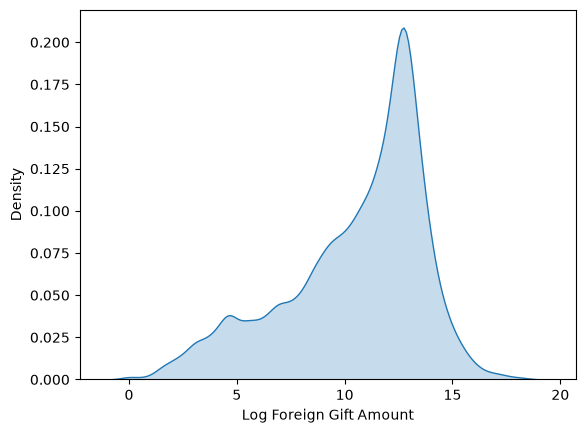

In [15]:
#Question 2 part 4
df["Log Foreign Gift Amount"] = np.log(df["Foreign Gift Amount"])  
sns.kdeplot(df["Log Foreign Gift Amount"], fill=True)

<Axes: xlabel='Log Foreign Gift Amount', ylabel='Density'>

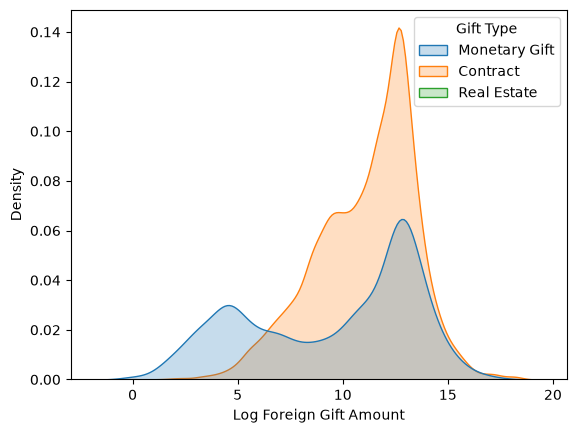

In [16]:
sns.kdeplot(df, x = "Log Foreign Gift Amount", fill=True, hue = "Gift Type")

The general distribution for foreign gift amount most closely follows the distribution for contracts when accounting for gift types. Since contract is the most prevelant type of gift, it has a larger influence on the combined distribution, therefore causing the combined graph to resemble the contract distribution more. Monetary gifts also has a simillar peak where there is a peak for contract, which reinforces the graph behavior for the combined graph. There is also a earlier peak for monetary gifts, which is subtly reflected in the combined graph at 5 on the x-axis. Real estate does not seem to influence either graphs much, since it is such a small porportion of the total gift amount. 

In [25]:
#Question 2 part 5
top_15_by_num_gifts = df.groupby("Country of Giftor")["Foreign Gift Amount"].count().nlargest(15)
top_15_by_amount_given = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().nlargest(15)
print("Top 15 Countries by Number of Gifts:\n", top_15_by_num_gifts)
print("\nTop 15 Countries by Total Amount Given:\n", top_15_by_amount_given)

Top 15 Countries by Number of Gifts:
 Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

Top 15 Countries by Total Amount Given:
 Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                4011

The top 15 countries by number of gifts are England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, the Netherlands, Korea, India, and Taiwan.

The top 15 countries by total amount given are Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, the United Arab Emirates, France, Singapore, and Australia.

In [34]:
#Question 2 part 6
most_amount_given_individual = df.groupby("Giftor Name")["Foreign Gift Amount"].sum().nlargest(1)
print(most_amount_given_individual)

Giftor Name
Qatar Foundation    1166503744
Name: Foreign Gift Amount, dtype: int64


The Qatar Foundation is the largest giftor, contributing $1166503744

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]